# D7 on D6c: 2.5D U-Net (Stack-5) under Label Noise
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392

**Strategy under test:** D6c — 2.5D U-Net with `stack_size=5`, Dice + CE loss



## 1. Noise Configuration — EDIT BETWEEN RUNS

In [9]:

NOISE_TYPE = 'combined'    # 'missing' | 'jitter' | 'combined' | None
NOISE_RATE = 0.50          # 0.20, 0.50, 0.70 

STRATEGY     = 'D6c'
NOISE_SEED   = 2026     
RESULTS_FILE = f'results_d7_{STRATEGY}.json'

config_tag = (
    f'{STRATEGY}__clean' if NOISE_TYPE is None
    else f'{STRATEGY}__{NOISE_TYPE}_r{int(round(NOISE_RATE*100)):02d}'
)
print(f'Strategy:    {STRATEGY}')
print(f'Noise type:  {NOISE_TYPE}')
print(f'Noise rate:  {NOISE_RATE if NOISE_TYPE else 0}')
print(f'Config tag:  {config_tag}')


Strategy:    D6c
Noise type:  combined
Noise rate:  0.5
Config tag:  D6c__combined_r50


## 2. Imports

In [10]:
import os, sys, json, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.utils.data import DataLoader

sys.path.insert(0, '.')
from lits_core import (
    get_device,
    load_lits_paths,
    make_split,
    LiTS25DDataset,
    UNet2D,
    train_model, 
    compute_dice_per_class,
)

DEVICE = get_device()
print(f'Device:   {DEVICE}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'PyTorch:  {torch.__version__}')


Device:   cuda
PyTorch:  2.11.0+cu128


## 3. Configuration

In [11]:
DATA_DIR     = '/home/adnan/aeman_dl/archive-2'

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400
STACK_SIZE     = 5  

print(f'Data:        {DATA_DIR}')
print(f'Stack size:  {STACK_SIZE}  (D6c: 5 slices vs D6: 3 slices)')
print(f'Img size:    {IMG_SIZE}')
print(f'Batch size:  {BATCH_SIZE}')
print(f'Epochs:      {NUM_EPOCHS}')
print(f'LR:          {LR}')


Data:        /home/adnan/aeman_dl/archive-2
Stack size:  5  (D6c: 5 slices vs D6: 3 slices)
Img size:    128
Batch size:  16
Epochs:      20
LR:          0.0001


## 4. Load Volumes and Split

In [12]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 5. Build Datasets — Train Noisy, Val Clean

In [13]:
print('Building train dataset...')
train_dataset = LiTS25DDataset(
    train_v, train_s,
    img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
    stack_size=STACK_SIZE,
    augment=False,               
    noise_type=NOISE_TYPE,
    noise_rate=NOISE_RATE if NOISE_TYPE else 0.0,
    noise_seed=NOISE_SEED,
)

print('\nBuilding val dataset (always clean)...')
val_dataset = LiTS25DDataset(
    val_v, val_s,
    img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
    stack_size=STACK_SIZE,
    augment=False,
    noise_type=None,               # CLEAN
    noise_rate=0.0,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Building train dataset...
Dataset: 4614 slices | stack=5 | augment=False (medium) | noise=combined@50% (2265 slices)

Building val dataset (always clean)...
Dataset: 1116 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 6. Sanity Check — Visualize Noisy Slices

For 2.5D, each sample is a stack of 5 slices but only the **center slice** has the segmentation we corrupt. Visualization shows the center slice (index 2 of the stack of 5).


Slices marked noisy: 2265 / 4614 (49.1%)
Dataset: 4614 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)


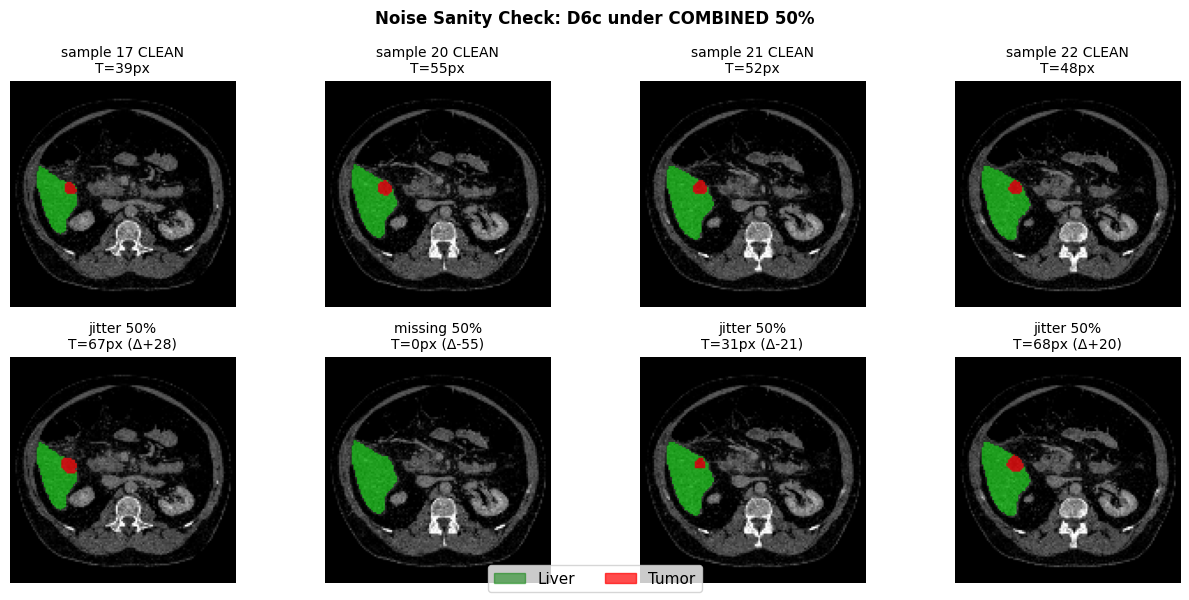

In [14]:
if NOISE_TYPE is None:
    print('Clean run — no noise to visualize.')
else:
    noisy_idxs = np.where(train_dataset._noisy_mask)[0]
    print(f'Slices marked noisy: {len(noisy_idxs)} / {len(train_dataset)} '
          f'({100*len(noisy_idxs)/len(train_dataset):.1f}%)')

    clean_dataset = LiTS25DDataset(
        train_v, train_s,
        img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
        stack_size=STACK_SIZE, augment=False,
        noise_type=None, noise_rate=0.0,
    )

    show = []
    for i in noisy_idxs:
        _, m_clean = clean_dataset[int(i)]
        if (m_clean == 2).sum().item() > 30:
            show.append(int(i))
        if len(show) >= 4:
            break

    if not show:
        print('No noisy slices with > 30 tumor pixels — try a higher rate.')
    else:
        center = STACK_SIZE // 2  
        fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 6))
        if len(show) == 1:
            axes = axes[:, None]
        for col, i in enumerate(show):
            ct, m_clean = clean_dataset[i]
            ct_img = ct[center].numpy()      # center slice
            m_clean_np = m_clean.numpy()
            _, m_noisy = train_dataset[i]
            m_noisy_np = m_noisy.numpy()

            ov = np.zeros((*ct_img.shape, 4))
            ov[m_clean_np == 1] = [0, 1, 0, 0.5]
            ov[m_clean_np == 2] = [1, 0, 0, 0.7]
            axes[0, col].imshow(ct_img.T, cmap='gray', origin='lower')
            axes[0, col].imshow(ov.transpose(1, 0, 2), origin='lower')
            t_px_c = (m_clean_np == 2).sum()
            axes[0, col].set_title(f'sample {i} CLEAN\nT={t_px_c}px', fontsize=10)
            axes[0, col].axis('off')

            ov = np.zeros((*ct_img.shape, 4))
            ov[m_noisy_np == 1] = [0, 1, 0, 0.5]
            ov[m_noisy_np == 2] = [1, 0, 0, 0.7]
            axes[1, col].imshow(ct_img.T, cmap='gray', origin='lower')
            axes[1, col].imshow(ov.transpose(1, 0, 2), origin='lower')
            t_px_n = (m_noisy_np == 2).sum()
            delta = int(t_px_n - t_px_c)
            kind = train_dataset._noisy_kinds[i] if NOISE_TYPE == 'combined' else NOISE_TYPE
            axes[1, col].set_title(
                f'{kind} {NOISE_RATE:.0%}\nT={t_px_n}px (Δ{delta:+d})',
                fontsize=10,
            )
            axes[1, col].axis('off')

        green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
        red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
        fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
        plt.suptitle(f'Noise Sanity Check: {STRATEGY} under {NOISE_TYPE.upper()} {NOISE_RATE:.0%}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


## 7. Build U-Net (in_channels=5)

In [15]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3,
               base_features=64, use_attention=False).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(f'(in_channels={STACK_SIZE}, base_features=64, no attention)')


Model parameters: 31,038,915
(in_channels=5, base_features=64, no attention)


## 8. Training (Dice + CE)



In [16]:
run_start = time.time()

history, best_state, best_tumor_dice = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    lr=LR,
    weight_decay=1e-5,
    tag=config_tag,
    save_path=f'best_{config_tag}.pth',
    verbose_batch_every=100,
    seed=SEED,
)

run_mins = (time.time() - run_start) / 60

best_idx = int(np.argmax(history['val_tumor_dice']))
best_tumor_dice = float(history['val_tumor_dice'][best_idx])
best_liver_at_best_tumor = float(history['val_liver_dice'][best_idx])
best_epoch = best_idx + 1

print(f'\nTotal training time: {run_mins:.1f} min')
print(f'Best tumor Dice: {best_tumor_dice:.4f} @ epoch {best_epoch} '
      f'(liver at that epoch: {best_liver_at_best_tumor:.4f})')


TRAINING: D6c__combined_r50
  Epochs=20 | LR=0.0001 | Device=cuda | Params=31,038,915
  Train batches: 289 | Val batches: 70
  [D6c__combined_r50] Ep 01 batch 100/289 loss=0.9601
  [D6c__combined_r50] Ep 01 batch 200/289 loss=0.8070
[D6c__combined_r50] Ep 01/20 |  4.2min | Train: 0.9290 | Val: 0.7305 | Liver: 0.8664 | Tumor: 0.5429 *** BEST
  [D6c__combined_r50] Ep 02 batch 100/289 loss=0.6034
  [D6c__combined_r50] Ep 02 batch 200/289 loss=0.5233
[D6c__combined_r50] Ep 02/20 |  2.2min | Train: 0.5816 | Val: 0.6133 | Liver: 0.7994 | Tumor: 0.0803
  [D6c__combined_r50] Ep 03 batch 100/289 loss=0.4167
  [D6c__combined_r50] Ep 03 batch 200/289 loss=0.4438
[D6c__combined_r50] Ep 03/20 |  2.2min | Train: 0.4418 | Val: 0.4966 | Liver: 0.8317 | Tumor: 0.4558
  [D6c__combined_r50] Ep 04 batch 100/289 loss=0.2746
  [D6c__combined_r50] Ep 04 batch 200/289 loss=0.3492
[D6c__combined_r50] Ep 04/20 |  2.2min | Train: 0.3653 | Val: 0.4373 | Liver: 0.8903 | Tumor: 0.3262
  [D6c__combined_r50] Ep 05 ba

## 9. Save Result to JSON

In [17]:
results_path = Path(RESULTS_FILE)
results = {}
if results_path.exists():
    with results_path.open() as f:
        results = json.load(f)

results[config_tag] = {
    'strategy':    STRATEGY,
    'noise_type':  NOISE_TYPE,
    'noise_rate':  NOISE_RATE if NOISE_TYPE else 0.0,
    'noise_seed':  NOISE_SEED,
    'liver_dice':  best_liver_at_best_tumor,
    'tumor_dice':  best_tumor_dice,
    'best_epoch':  best_epoch,
    'history':     history,
    'num_epochs':  NUM_EPOCHS,
    'run_minutes': float(run_mins),
    'stack_size':  STACK_SIZE,
}

with results_path.open('w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'Saved {config_tag} to {RESULTS_FILE}\n')
print(f'All entries currently in {RESULTS_FILE}:')
for k, v in sorted(results.items()):
    print(f'  {k:30s}  liver={v["liver_dice"]:.4f}  tumor={v["tumor_dice"]:.4f}  '
          f'epoch={v["best_epoch"]}')


Saved D6c__combined_r50 to results_d7_D6c.json

All entries currently in results_d7_D6c.json:
  D6c__combined_r50               liver=0.8874  tumor=0.5971  epoch=11


## 10. Plot Degradation Curve


In [18]:

D6C_CLEAN_LIVER = 0.8941     
D6C_CLEAN_TUMOR = 0.5749    

with results_path.open() as f:
    results = json.load(f)

if NOISE_TYPE is None:
    print('Clean run — no degradation curve to plot.')
else:
    matching = [v for v in results.values()
                if v.get('strategy') == STRATEGY
                and v.get('noise_type') == NOISE_TYPE]

    if len(matching) < 2:
        print(f'Only {len(matching)} entries for {STRATEGY} x {NOISE_TYPE}; need >=2.')
    else:
        points = []
        if D6C_CLEAN_LIVER is not None and D6C_CLEAN_TUMOR is not None:
            points.append((0.0, D6C_CLEAN_LIVER, D6C_CLEAN_TUMOR))
        for e in sorted(matching, key=lambda x: x['noise_rate']):
            points.append((e['noise_rate'], e['liver_dice'], e['tumor_dice']))

        rates = [p[0] for p in points]
        liver = [p[1] for p in points]
        tumor = [p[2] for p in points]

        fig, ax = plt.subplots(figsize=(7.5, 4.8))
        ax.plot(rates, liver, 'o-', color='#2a9d8f', linewidth=2, markersize=9, label='Liver')
        ax.plot(rates, tumor, 's-', color='#e63946', linewidth=2, markersize=9, label='Tumor')
        for r, l, t in zip(rates, liver, tumor):
            ax.annotate(f'{l:.3f}', (r, l), textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9, color='#2a9d8f')
            ax.annotate(f'{t:.3f}', (r, t), textcoords='offset points', xytext=(0, -15),
                        ha='center', fontsize=9, color='#e63946')
        ax.set_xlabel(f'{NOISE_TYPE} noise rate', fontsize=11)
        ax.set_ylabel('Validation Dice (clean labels)', fontsize=11)
        ax.set_title(f'D7: {STRATEGY} (stack=5) degradation under {NOISE_TYPE.upper()} noise',
                     fontsize=12, fontweight='bold')
        ax.set_xticks(rates)
        ax.set_xticklabels([f'{r:.0%}' for r in rates])
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower left')
        plt.tight_layout()
        out_png = f'd7_{STRATEGY}_{NOISE_TYPE}_curve.png'
        plt.savefig(out_png, dpi=130)
        plt.show()
        print(f'Saved {out_png}')


Only 1 entries for D6c x combined; need >=2.
